<a href="https://colab.research.google.com/github/jgarg9161-rinku/Europen-bank-churn-project/blob/main/Europen_bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Training.csv to Training (1).csv


In [ ]:
import pandas as pd

df_training = pd.read_csv('Training.csv')
df_testing = pd.read_csv('Testing.csv')

print('df_training head:')
print(df_training.head())
print('\ndf_testing head:')
print(df_testing.head())

df_training head:
   Exited  Scaled Score  France  Spain  Male  Scaled Age  Scaled Tenure  \
0       1         -0.33       0      1     0        0.20           1.03   
1       1         -0.34       0      0     0        0.10          -1.73   
2       1          0.56       0      0     0        0.39           1.72   
3       1          1.05       0      1     0       -0.37          -1.04   
4       1         -1.73       1      0     0        0.48           0.00   

   Scaled Balance  NumOfProducts Balance to Salary ratio  ...  IsActiveMember  \
0           -1.23              3                      0%  ...               1   
1            1.02              1                     87%  ...               0   
2            1.12              1                   1455%  ...               1   
3           -1.23              1                      0%  ...               0   
4            0.97              1                     71%  ...               0   

   Female Germany  Age  Tenure  HasCrCard   

In [ ]:
print('df_training head:')
print(df_training.head())
print('\n')
print('df_testing head:')
print(df_testing.head())

print('\n--- df_training Info ---')
df_training.info()
print('\n--- df_testing Info ---')
df_testing.info()

print('\n--- df_training Missing Values ---')
print(df_training.isnull().sum())
print('\n--- df_testing Missing Values ---')
print(df_testing.isnull().sum())

df_training head:
   Exited  Scaled Score  France  Spain  Male  Scaled Age  Scaled Tenure  \
0       1         -0.33       0      1     0        0.20           1.03   
1       1         -0.34       0      0     0        0.10          -1.73   
2       1          0.56       0      0     0        0.39           1.72   
3       1          1.05       0      1     0       -0.37          -1.04   
4       1         -1.73       1      0     0        0.48           0.00   

   Scaled Balance  NumOfProducts Balance to Salary ratio  ...  IsActiveMember  \
0           -1.23              3                      0%  ...               1   
1            1.02              1                     87%  ...               0   
2            1.12              1                   1455%  ...               1   
3           -1.23              1                      0%  ...               0   
4            0.97              1                     71%  ...               0   

   Female Germany  Age  Tenure  HasCrCard   

In [ ]:
y_train = df_training['Exited']
X_train = df_training.iloc[:, 1:15] # Subsequent 14 columns after 'Exited'

y_test = df_testing['Exited']
X_test = df_testing.iloc[:, 1:15] # Subsequent 14 columns after 'Exited'

print('X_train head:')
print(X_train.head())
print('\ny_train head:')
print(y_train.head())
print('\nX_test head:')
print(X_test.head())
print('\ny_test head:')
print(y_test.head())

X_train head:
   Scaled Score  France  Spain  Male  Scaled Age  Scaled Tenure  \
0         -0.33       0      1     0        0.20           1.03   
1         -0.34       0      0     0        0.10          -1.73   
2          0.56       0      0     0        0.39           1.72   
3          1.05       0      1     0       -0.37          -1.04   
4         -1.73       1      0     0        0.48           0.00   

   Scaled Balance  NumOfProducts Balance to Salary ratio  \
0           -1.23              3                      0%   
1            1.02              1                     87%   
2            1.12              1                   1455%   
3           -1.23              1                      0%   
4            0.97              1                     71%   

   Product to tenure ratio  Age Tenure Engagement Score  Scaled Salary   \
0                     0.38        0.20              38%           -0.35   
1                     1.00        0.00               0%            1.05 

In [ ]:
print('--- X_train Columns before renaming ---')
print(X_train.columns.tolist())
print('\n--- X_test Columns before renaming ---')
print(X_test.columns.tolist())

# Correcting column names by removing trailing spaces
X_train.columns = X_train.columns.str.strip()
X_test.columns = X_test.columns.str.strip()

print('\n--- X_train Columns after renaming ---')
print(X_train.columns.tolist())
print('\n--- X_test Columns after renaming ---')
print(X_test.columns.tolist())

columns_to_clean = ['Scaled Score', 'Scaled Age', 'Scaled Tenure', 'Scaled Balance', 'Engagement Score', 'Scaled Salary']
print('\n--- columns_to_clean list ---')
print(columns_to_clean)

# Re-attempt cleaning and conversion with specific handling for 'Engagement Score'
for col in columns_to_clean:
    cleaned_series_train = X_train[col].astype(str).str.replace('(', '', regex=False).str.replace(')', '', regex=False)
    cleaned_series_test = X_test[col].astype(str).str.replace('(', '', regex=False).str.replace(')', '', regex=False)

    if col == 'Engagement Score':
        cleaned_series_train = cleaned_series_train.str.replace('%', '', regex=False)
        cleaned_series_test = cleaned_series_test.str.replace('%', '', regex=False)

    X_train[col] = cleaned_series_train.astype(float)
    X_test[col] = cleaned_series_test.astype(float)

# Clean and convert 'Balance to Salary ratio'
X_train['Balance to Salary ratio'] = X_train['Balance to Salary ratio'].astype(str).str.replace('%', '', regex=False).astype(float) / 100
X_test['Balance to Salary ratio'] = X_test['Balance to Salary ratio'].astype(str).str.replace('%', '', regex=False).astype(float) / 100

print('\n--- X_train Info after cleaning ---')
X_train.info()
print('\n--- X_test Info after cleaning ---')
X_test.info()

--- X_train Columns before renaming ---
['Scaled Score', 'France', 'Spain', 'Male', 'Scaled Age', 'Scaled Tenure', 'Scaled Balance', 'NumOfProducts', 'Balance to Salary ratio', 'Product to tenure ratio', 'Age Tenure', 'Engagement Score', 'Scaled Salary', 'IsActiveMember']

--- X_test Columns before renaming ---
['Scaled Score', 'France', 'Spain', 'Male', 'Scaled Age', 'Scaled Tenure', 'Scaled Balance', 'NumOfProducts', 'Balance to Salary ratio', 'Product to tenure ratio', 'Age Tenure', 'Engagement Score', 'Scaled Salary', 'IsActiveMember']

--- X_train Columns after renaming ---
['Scaled Score', 'France', 'Spain', 'Male', 'Scaled Age', 'Scaled Tenure', 'Scaled Balance', 'NumOfProducts', 'Balance to Salary ratio', 'Product to tenure ratio', 'Age Tenure', 'Engagement Score', 'Scaled Salary', 'IsActiveMember']

--- X_test Columns after renaming ---
['Scaled Score', 'France', 'Spain', 'Male', 'Scaled Age', 'Scaled Tenure', 'Scaled Balance', 'NumOfProducts', 'Balance to Salary ratio', 'Prod

In [ ]:
from xgboost import XGBClassifier

# Initialize the XGBClassifier model
xgb_model = XGBClassifier(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


Accuracy: 0.8519
Precision: 0.6881
Recall: 0.4988
F1-Score: 0.5783

Confusion Matrix:
[[1500   92]
 [ 204  203]]


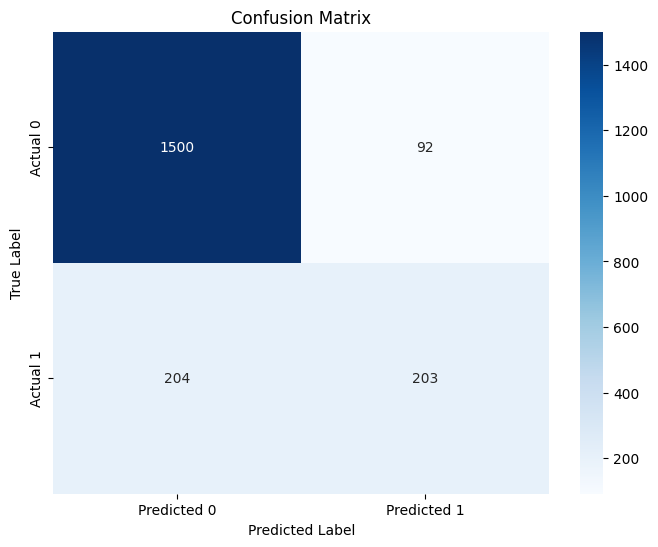

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Logistic Regression Accuracy: 0.8134
Logistic Regression Precision: 0.6104
Logistic Regression Recall: 0.2310
Logistic Regression F1-Score: 0.3351

Logistic Regression Confusion Matrix:
[[1532   60]
 [ 313   94]]


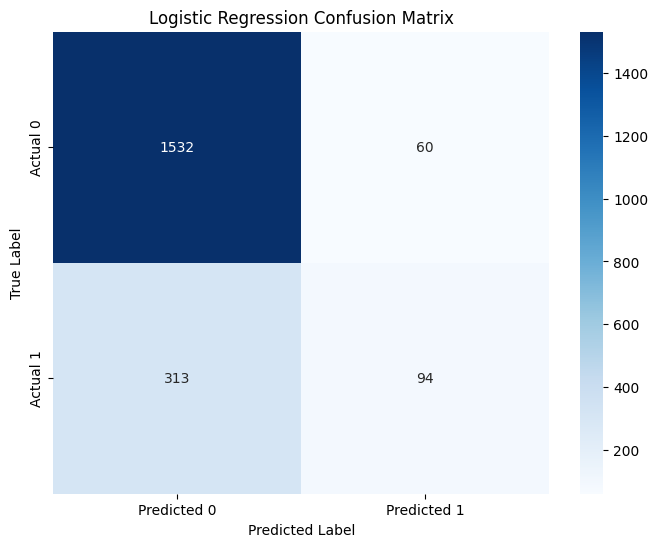

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for smaller datasets
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set using the Logistic Regression model
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate performance metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_log_reg)
precision_lr = precision_score(y_test, y_pred_log_reg)
recall_lr = recall_score(y_test, y_pred_log_reg)
f1_lr = f1_score(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Recall: {recall_lr:.4f}")
print(f"Logistic Regression F1-Score: {f1_lr:.4f}")

# Generate confusion matrix for Logistic Regression
conf_matrix_lr = confusion_matrix(y_test, y_pred_log_reg)
print("\nLogistic Regression Confusion Matrix:")
print(conf_matrix_lr)

# Visualize confusion matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and L1/L2 regularization

# Train the model
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


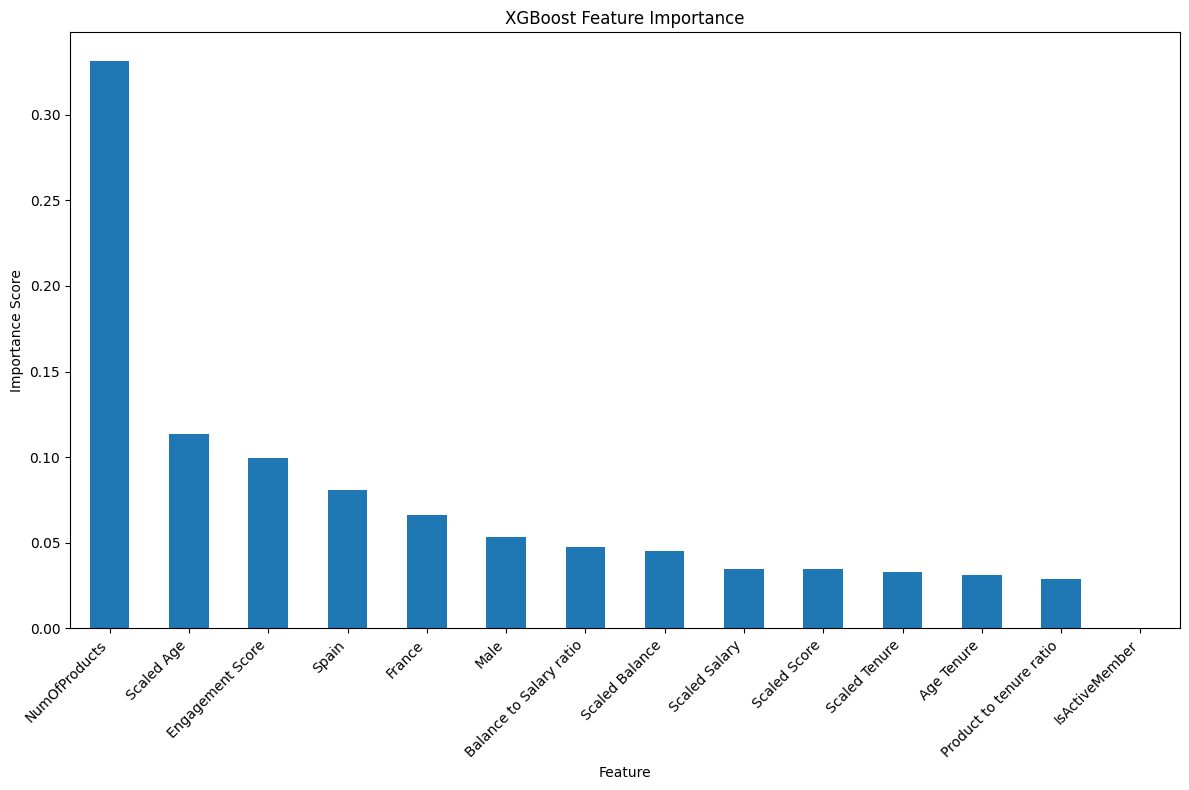

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances
feature_importances = xgb_model.feature_importances_

# Create a pandas Series with feature names and their importances
feature_names = X_train.columns
feature_importance_series = pd.Series(feature_importances, index=feature_names)

# Sort feature importances in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sorted_feature_importances.plot(kind='bar')
plt.title('XGBoost Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
pip install shap

In [ ]:
import shap

# Initialize a SHAP TreeExplainer with the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Compute SHAP values for the X_test dataset
shap_values = explainer.shap_values(X_test)

print("SHAP TreeExplainer initialized and SHAP values computed successfully.")

SHAP TreeExplainer initialized and SHAP values computed successfully.


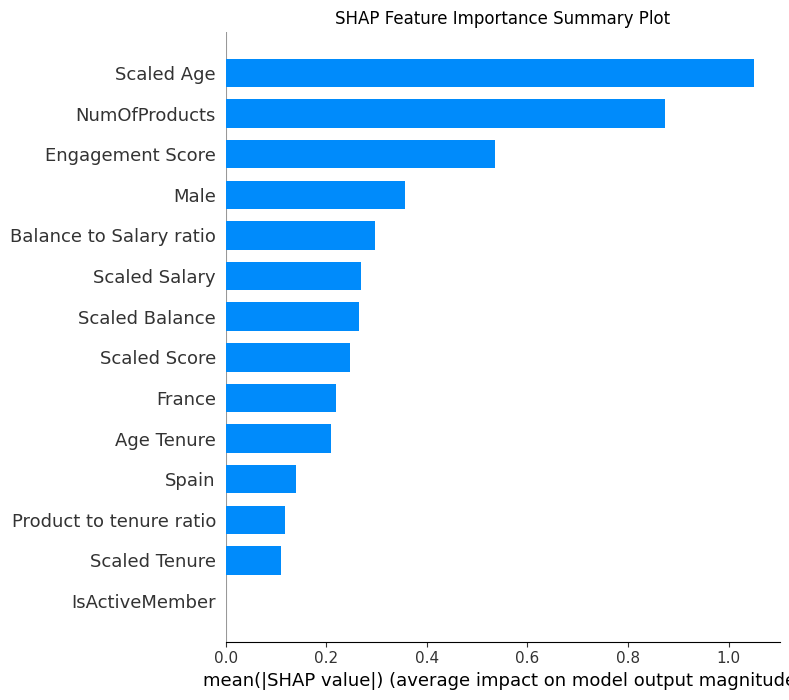

In [ ]:
import matplotlib.pyplot as plt

# Generate a SHAP summary plot (bar plot for overall feature importance)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

plt.title('SHAP Feature Importance Summary Plot')
plt.tight_layout()
plt.show()

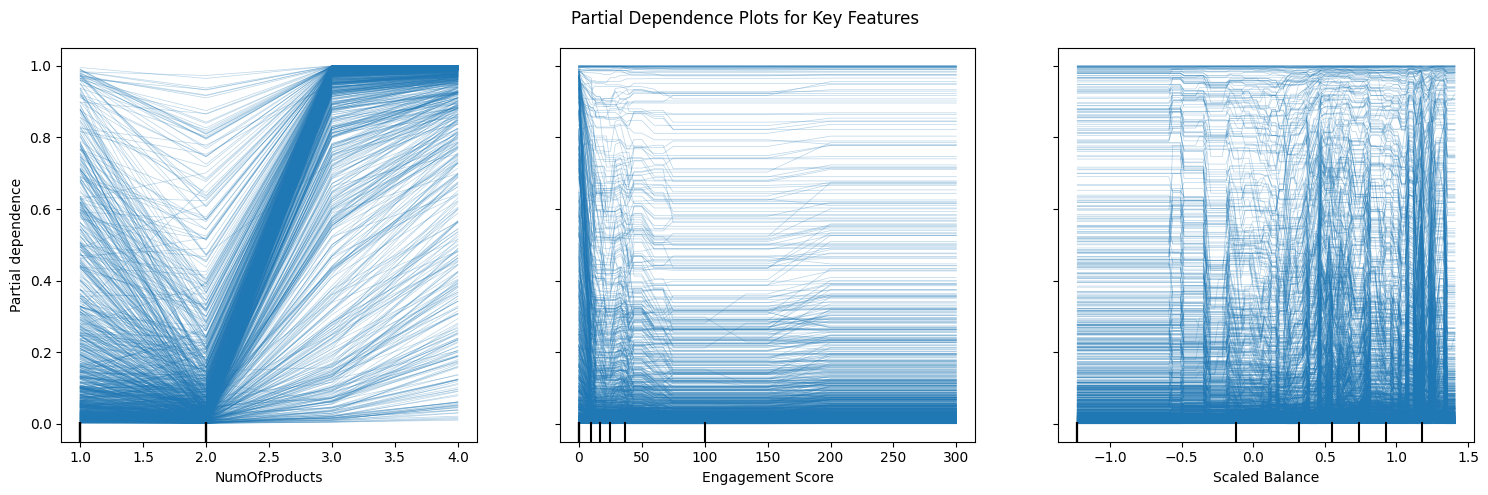

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Define the features for which to plot PDPs
features_for_pdp = ['NumOfProducts', 'Engagement Score', 'Scaled Balance']

# Create the Partial Dependence Plots
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(
    xgb_model, X_test, features_for_pdp, kind='individual', ax=ax, feature_names=X_test.columns
)
plt.suptitle('Partial Dependence Plots for Key Features')
plt.tight_layout()
plt.show()


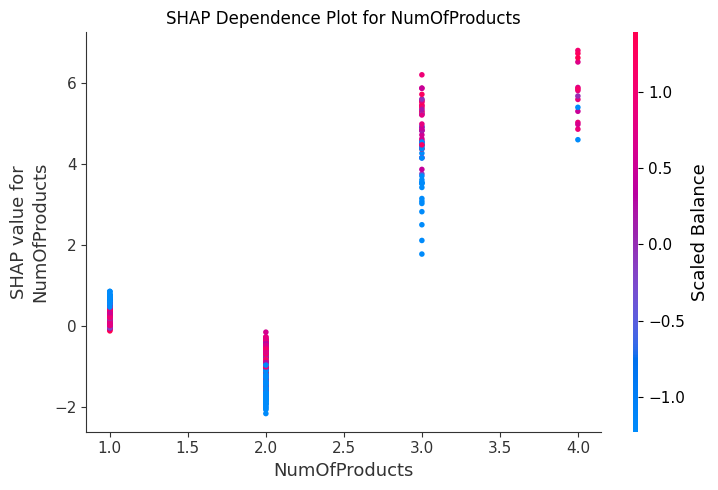

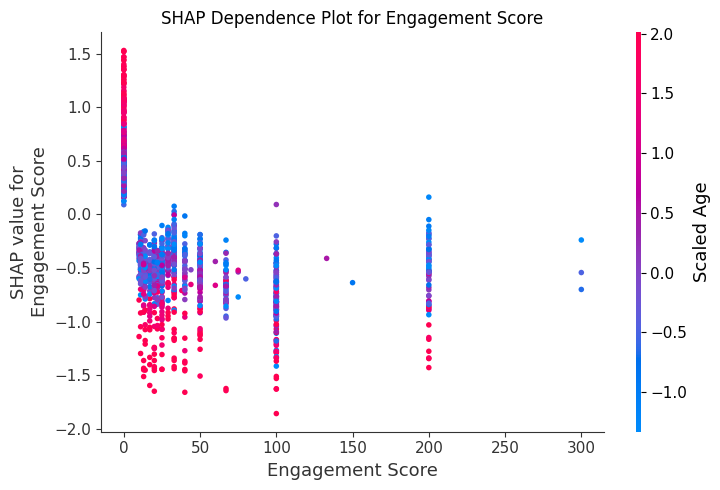

In [ ]:
import matplotlib.pyplot as plt

# Generate SHAP dependence plot for 'NumOfProducts'
shap.dependence_plot('NumOfProducts', shap_values, X_test, show=False)
plt.title('SHAP Dependence Plot for NumOfProducts')
plt.tight_layout()
plt.show()

# Generate SHAP dependence plot for 'Engagement Score'
shap.dependence_plot('Engagement Score', shap_values, X_test, show=False)
plt.title('SHAP Dependence Plot for Engagement Score')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")


Decision Tree model trained successfully.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
random_forest_model = RandomForestClassifier(random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


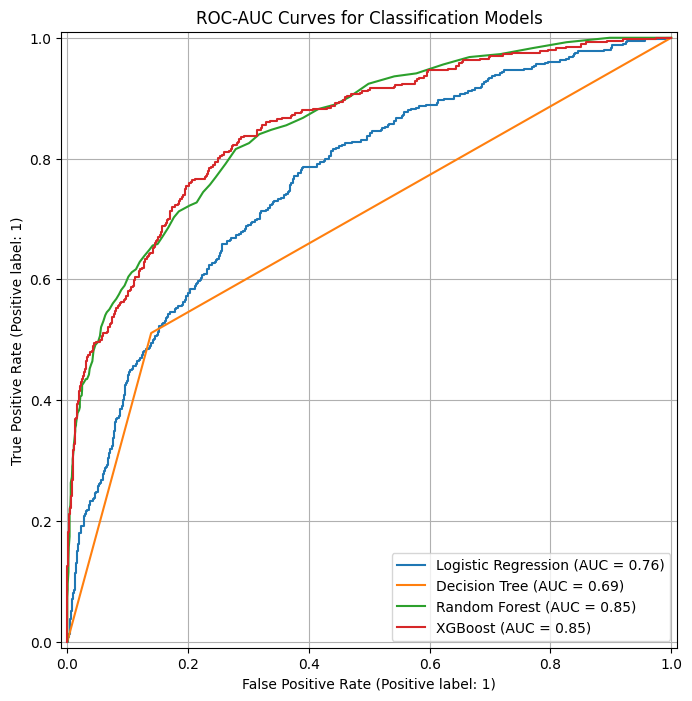

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC-AUC curve for Logistic Regression
RocCurveDisplay.from_estimator(log_reg_model, X_test, y_test, ax=ax, name='Logistic Regression')

# Plot ROC-AUC curve for Decision Tree
RocCurveDisplay.from_estimator(decision_tree_model, X_test, y_test, ax=ax, name='Decision Tree')

# Plot ROC-AUC curve for Random Forest
RocCurveDisplay.from_estimator(random_forest_model, X_test, y_test, ax=ax, name='Random Forest')

# Plot ROC-AUC curve for XGBoost
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, ax=ax, name='XGBoost')

# Add title and legend
ax.set_title('ROC-AUC Curves for Classification Models')
ax.legend(loc='lower right')
plt.grid(True)
plt.show()

TRAINING SET EVALUATION
Training Accuracy : 1.0

Training Confusion Matrix
[[6371    0]
 [   0 1630]]

Training Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6371
           1       1.00      1.00      1.00      1630

    accuracy                           1.00      8001
   macro avg       1.00      1.00      1.00      8001
weighted avg       1.00      1.00      1.00      8001



TEST SET EVALUATION
Testing Accuracy : 0.863431715857929

Testing Confusion Matrix
[[1545   47]
 [ 226  181]]

Testing Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1592
           1       0.79      0.44      0.57       407

    accuracy                           0.86      1999
   macro avg       0.83      0.71      0.74      1999
weighted avg       0.86      0.86      0.85      1999



TOP FEATURE IMPORTANCE
                        Feature  Importance


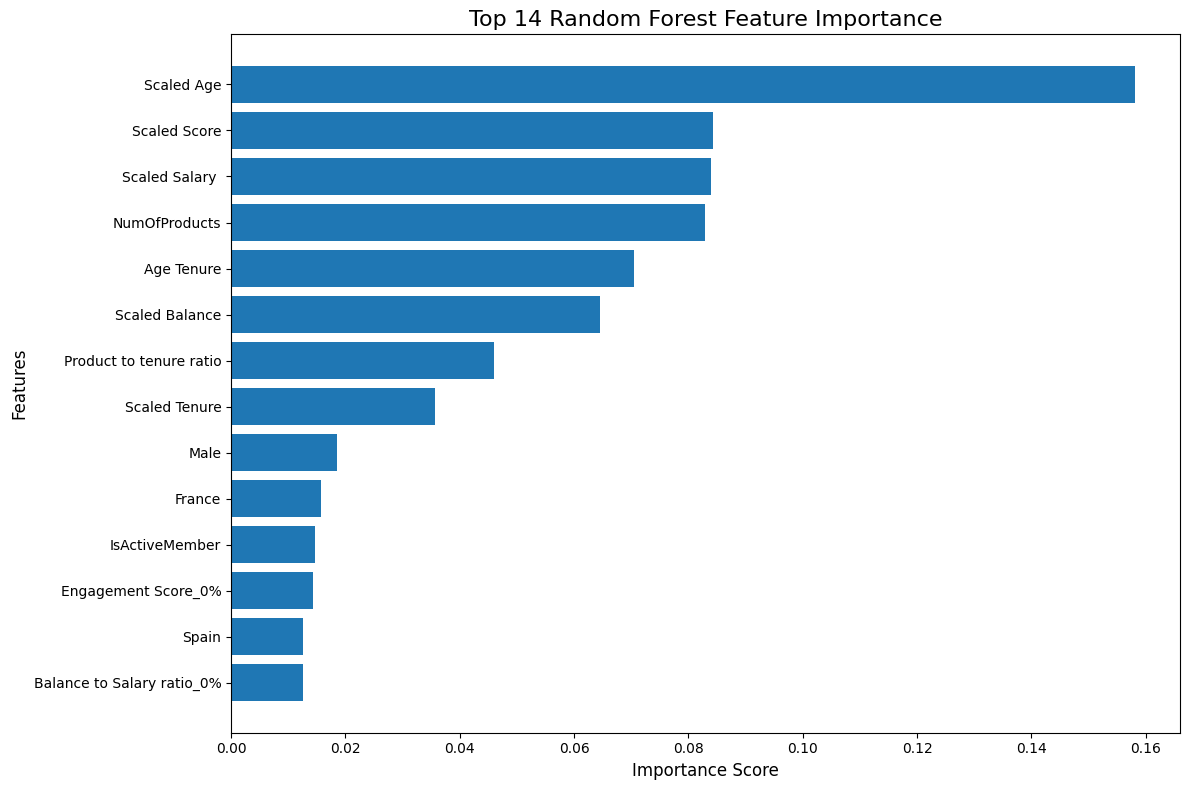

In [ ]:
# =========================================================
# RANDOM FOREST MODEL + EVALUATION + IMPROVED GRAPH
# =========================================================

# STEP 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# =========================================================
# STEP 2: LOAD CSV FILES
# =========================================================

train_data = pd.read_csv('/content/Training.csv')
test_data = pd.read_csv('/content/Testing.csv')

# =========================================================
# STEP 3: SELECT 14 FEATURES (EXCLUDING FIRST COLUMN)
# =========================================================

# Target Column
y_train = train_data['Exited']
y_test = test_data['Exited']

# 14 Features
X_train = train_data.iloc[:, 1:15]
X_test = test_data.iloc[:, 1:15]

# =========================================================
# STEP 4: CONVERT TEXT DATA INTO NUMERIC
# =========================================================

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Match Columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# =========================================================
# STEP 5: CREATE RANDOM FOREST MODEL
# =========================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# =========================================================
# TRAINING SET EVALUATION
# =========================================================

train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

print("===================================")
print("TRAINING SET EVALUATION")
print("===================================")

print("Training Accuracy :", train_accuracy)

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, train_pred))

print("\nTraining Classification Report")
print(classification_report(y_train, train_pred))

# =========================================================
# TEST SET EVALUATION
# =========================================================

test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)

print("\n\n===================================")
print("TEST SET EVALUATION")
print("===================================")

print("Testing Accuracy :", test_accuracy)

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, test_pred))

print("\nTesting Classification Report")
print(classification_report(y_test, test_pred))

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort Feature Importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n\n===================================")
print("TOP FEATURE IMPORTANCE")
print("===================================")

print(feature_importance.head(14))

# =========================================================
# IMPROVED FEATURE IMPORTANCE GRAPH
# =========================================================

# Select Top 14 Features
top_features = feature_importance.head(14)

# Graph Size
plt.figure(figsize=(12,8))

# Horizontal Bar Graph
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

# Labels
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Title
plt.title(
    "Top 14 Random Forest Feature Importance",
    fontsize=16
)

# Highest Value on Top
plt.gca().invert_yaxis()

# Improve Layout
plt.tight_layout()

# Show Graph
plt.show()

TRAINING SET EVALUATION
Training Accuracy : 0.8487689038870141

Training Confusion Matrix
[[6139  232]
 [ 978  652]]

Training Classification Report
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      6371
           1       0.74      0.40      0.52      1630

    accuracy                           0.85      8001
   macro avg       0.80      0.68      0.71      8001
weighted avg       0.84      0.85      0.83      8001



TEST SET EVALUATION
Testing Accuracy : 0.8609304652326163

Testing Confusion Matrix
[[1536   56]
 [ 222  185]]

Testing Classification Report
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1592
           1       0.77      0.45      0.57       407

    accuracy                           0.86      1999
   macro avg       0.82      0.71      0.74      1999
weighted avg       0.85      0.86      0.85      1999



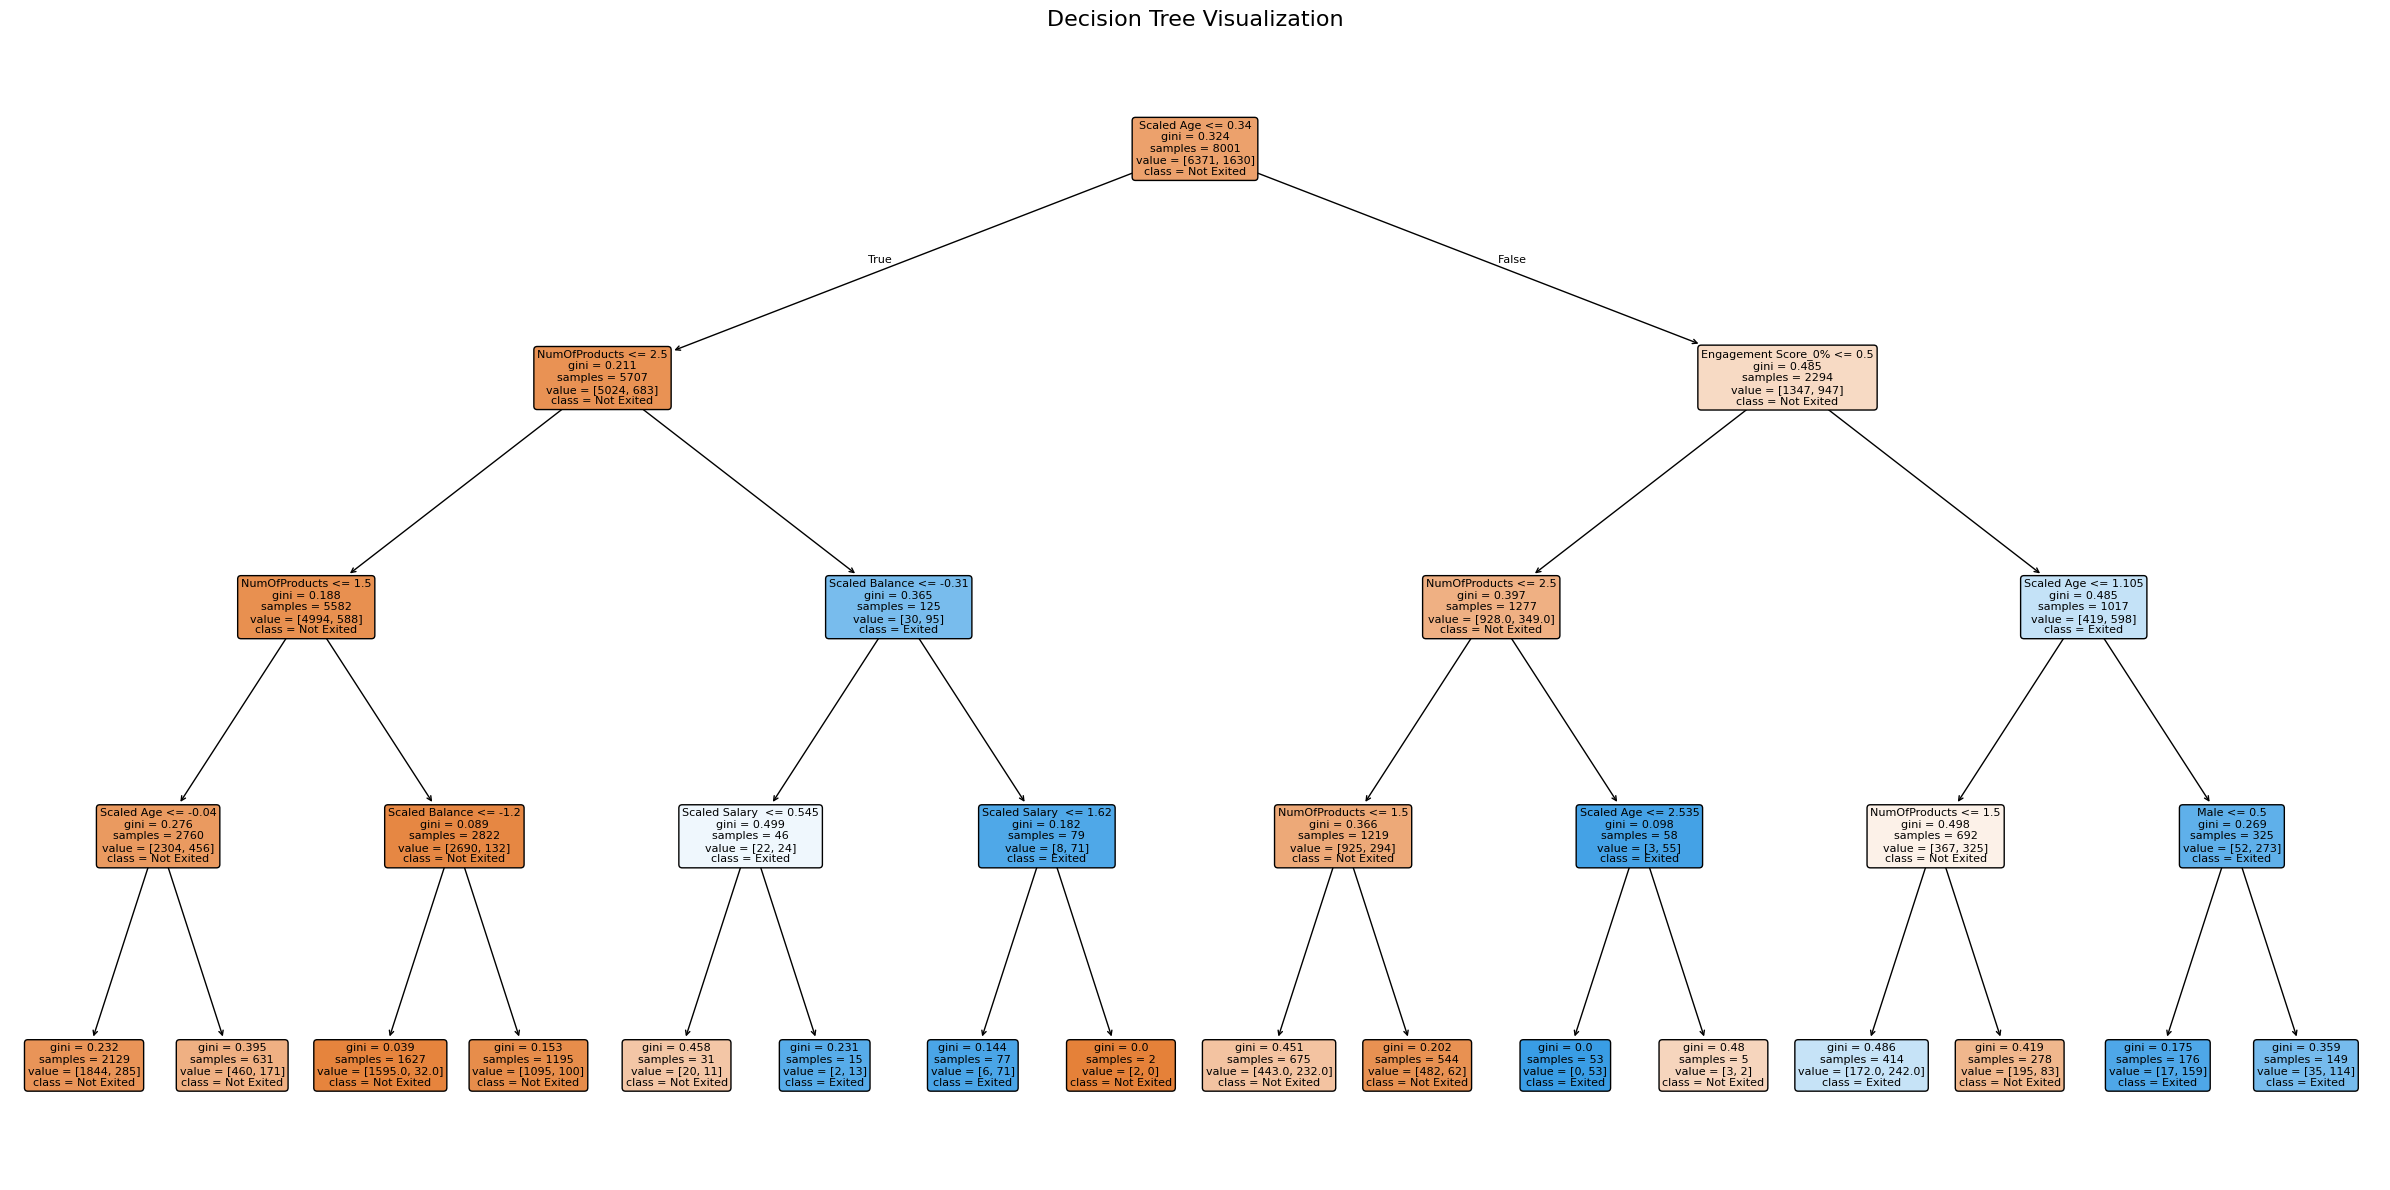

In [ ]:
# =====================================================
# DECISION TREE MODEL + EVALUATION + VISUALIZATION
# =====================================================

# STEP 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# =====================================================
# STEP 2: LOAD CSV FILES
# =====================================================

train_data = pd.read_csv('/content/Training.csv')
test_data = pd.read_csv('/content/Testing.csv')

# =====================================================
# STEP 3: DEFINE INPUT AND OUTPUT
# =====================================================

# Target Column
y_train = train_data['Exited']
y_test = test_data['Exited']

# Features
X_train = train_data.iloc[:, 1:15]
X_test = test_data.iloc[:, 1:15]

# =====================================================
# STEP 4: CONVERT TEXT DATA INTO NUMERIC
# =====================================================

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Match Columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# =====================================================
# STEP 5: CREATE DECISION TREE MODEL
# =====================================================

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# =====================================================
# TRAINING SET EVALUATION
# =====================================================

train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

print("===================================")
print("TRAINING SET EVALUATION")
print("===================================")

print("Training Accuracy :", train_accuracy)

print("\nTraining Confusion Matrix")
print(confusion_matrix(y_train, train_pred))

print("\nTraining Classification Report")
print(classification_report(y_train, train_pred))

# =====================================================
# TEST SET EVALUATION
# =====================================================

test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)

print("\n\n===================================")
print("TEST SET EVALUATION")
print("===================================")

print("Testing Accuracy :", test_accuracy)

print("\nTesting Confusion Matrix")
print(confusion_matrix(y_test, test_pred))

print("\nTesting Classification Report")
print(classification_report(y_test, test_pred))

# =====================================================
# DECISION TREE VISUALIZATION
# =====================================================

plt.figure(figsize=(24,12))

plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=['Not Exited', 'Exited'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Decision Tree Visualization",
    fontsize=16
)

plt.tight_layout()

plt.show()